# Fine motor study: review and exploratory analysis

This notebook reviews acquired trials for **control vs disease**, under `normal_dom`, `normal_ndom`, `blind_dom`, and `blind_ndom`. Run from top to bottom, then edit the configuration and rerun as needed. `main.ipynb` acquires data; the Python modules beside it implement analysis and replay.

**Task:** start with hands at rest at shoulder width, pick up a lock and key, unlock it, then return to rest.

**What the data can tell us:** wrist-relative fingertip movement, thumb–index spacing, movement variability, and acquisition quality. Without a specified target/task, dispersion is **not target error or a validated precision score**. Intentional movement, hand rotation, camera noise, and tracking error all contribute. These outputs are exploratory study summaries, not a diagnostic classifier.

The saved x/y positions are normalized image coordinates; z is estimated depth relative to the wrist, not a calibrated physical point cloud. No millimetres or absolute 3D speed are inferred. See [MediaPipe coordinates](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python).


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from proj.session import DEFAULT_DATA_DIR
from proj.review_data import discover_trials, prepare_group_file, apply_recording_exclusions
from proj.motor_metrics import extract_metrics, PRIMARY_METRICS, METRICS
from proj.study_statistics import (
    subject_summary, descriptive_statistics, compare_groups, paired_condition_effects, balanced_overall_summary,
)
from proj.review_plots import plot_group_distributions, plot_paired_conditions, display_figure_once
from proj.landmark_replay import review_widget
from proj.task_analysis import add_task_metrics, TASK_OUTCOMES, outcome_counts

DATA_DIR = DEFAULT_DATA_DIR
EXPORT_DIR = DATA_DIR.parent / "analysis_exports"

# Optional overrides; dominant hand is normally loaded from recording metadata/subject CSV.
# Example: {"Alice": "right", "Bob": "left"}
DOMINANT_HANDS = {}
# Override a specific trial if needed: {"Alice/trial_folder": "right"}
HAND_OVERRIDES = {}
# Exclude recordings from all statistics; use exact trial_id values from the inventory.
# Example: {"Alice/trial_folder": "Tracking lost during recording"}
EXCLUDED_RECORDINGS = {"ms3/blind_dom_2026-10-08_12-23-32_556642" : "Trial not finished"}
# Legacy CSV hand indices are not stable identities. Enable only after visual review.
ALLOW_LEGACY_HAND_INDEX = False
LEGACY_IMAGE_SIZE = None  # e.g. (640, 480), only if these were the actual capture dimensions

# Pre-specify quality thresholds and outcomes before inspecting group differences.
MIN_FRAMES = 30
MIN_COVERAGE = 0.8
MIN_DURATION_SECONDS = 1.0
MIN_HANDEDNESS_CONFIDENCE = 0.6
MAX_DERIVATIVE_GAP_SECONDS = 0.25
OUTCOMES = list(TASK_OUTCOMES)
WHOLE_TRIAL_OUTCOMES = ["recording_duration_seconds", *METRICS]
SUCCESSFUL_TASKS_ONLY = True  # Success is assumed for the single-event protocol.
MIN_REST_PHASE_FRAMES = 10


## 1. Recordings and group assignment

New recordings prompt once for `control` or `disease` and also ask which hand is dominant, and save both in metadata and `data/subject_groups.csv`. The CSV has `subject_name`, `group`, and `dominant_hand` columns; use `left` or `right` for handedness. For old recordings, this cell creates a subject/group template. Edit its blank group cells, save, and rerun this cell. The registry takes precedence over trial metadata, so any corrected assignment applies consistently to all that subject's trials. Unassigned subjects are visible for review but excluded from group inference. Subject names are matched exactly.

To exclude individual recordings, add their exact `trial_id` and a reason to `EXCLUDED_RECORDINGS` in the configuration cell, then rerun from the top. They remain visible for replay and in exported trial tables, but are excluded from all movement and event statistics. Unknown IDs raise an error to catch typos. Remove an entry to include it again, subject to the usual quality checks.

Cancelled/interrupted recordings remain in the inventory but are excluded from analysis. Existing directories in both naming schemes are discovered.


In [2]:
inventory = discover_trials(DATA_DIR)
group_file = prepare_group_file(inventory, DATA_DIR)
inventory = discover_trials(DATA_DIR)
print(f"Group registry: {group_file}")
print(f"Found {len(inventory)} trials, {inventory.subject_name.nunique()} subjects.")
display(inventory)
if inventory.empty:
    print("No acquired trials yet. Record with main.ipynb, then rerun this notebook.")
else:
    display(inventory.groupby(["group", "experiment_type", "status"], dropna=False).size().rename("trials").reset_index())
    missing_groups = inventory.loc[inventory.group == "", "subject_name"].unique()
    if len(missing_groups):
        print(f"Assign groups in the registry: {list(missing_groups)}")


Group registry: /home/jakub/Projects/proj/data/subject_groups.csv
Found 97 trials, 16 subjects.


,trial_id,subject_name,group,experiment_type,status,frames_recorded,duration_seconds,dominant_hand,csv_path,metadata_path,error
0,Consti/blind_dom_2026-10-08_15-06-38_039322,Consti,control,blind_dom,completed,119,8.641592,right,/home/jakub/Projects/proj/data/Consti/blind_do...,/home/jakub/Projects/proj/data/Consti/blind_do...,
1,Consti/blind_dom_2026-10-08_15-07-40_143253,Consti,control,blind_dom,completed,93,6.754534,right,/home/jakub/Projects/proj/data/Consti/blind_do...,/home/jakub/Projects/proj/data/Consti/blind_do...,
2,Consti/blind_ndom_2026-10-08_15-07-24_080716,Consti,control,blind_ndom,completed,115,8.415000,right,/home/jakub/Projects/proj/data/Consti/blind_nd...,/home/jakub/Projects/proj/data/Consti/blind_nd...,
3,Consti/blind_ndom_2026-10-08_15-08-40_381941,Consti,control,blind_ndom,completed,72,5.239057,right,/home/jakub/Projects/proj/data/Consti/blind_nd...,/home/jakub/Projects/proj/data/Consti/blind_nd...,
4,Consti/normal_dom_2026-10-08_15-06-57_405008,Consti,control,normal_dom,completed,84,6.136745,right,/home/jakub/Projects/proj/data/Consti/normal_d...,/home/jakub/Projects/proj/data/Consti/normal_d...,
...,...,...,...,...,...,...,...,...,...,...,...
92,ms5/blind_ndom_2026-10-08_15-46-15_096941,ms5,disease,blind_ndom,completed,224,12.695408,right,/home/jakub/Projects/proj/data/ms5/blind_ndom_...,/home/jakub/Projects/proj/data/ms5/blind_ndom_...,
93,ms5/normal_dom_2026-10-08_15-43-22_057294,ms5,disease,normal_dom,completed,257,14.364373,right,/home/jakub/Projects/proj/data/ms5/normal_dom_...,/home/jakub/Projects/proj/data/ms5/normal_dom_...,
94,ms5/normal_dom_2026-10-08_15-46-44_993312,ms5,disease,normal_dom,completed,144,9.301101,right,/home/jakub/Projects/proj/data/ms5/normal_dom_...,/home/jakub/Projects/proj/data/ms5/normal_dom_...,
95,ms5/normal_ndom_2026-10-08_15-45-56_323987,ms5,disease,normal_ndom,completed,97,6.888227,right,/home/jakub/Projects/proj/data/ms5/normal_ndom...,/home/jakub/Projects/proj/data/ms5/normal_ndom...,


,group,experiment_type,status,trials
0,control,blind_dom,cancelled,1
1,control,blind_dom,completed,14
2,control,blind_ndom,completed,14
3,control,normal_dom,cancelled,1
4,control,normal_dom,completed,14
5,control,normal_ndom,completed,14
6,disease,blind_dom,completed,10
7,disease,blind_ndom,cancelled,1
8,disease,blind_ndom,completed,9
9,disease,normal_dom,completed,9


## 2. Quality and movement features

Choose the **task hand**, not detection index 0/1. Dominant hand comes from `subject_groups.csv` or recording metadata; `DOMINANT_HANDS` can override it. The `_dom`/`_ndom` condition selects the corresponding hand. Otherwise, auto-selection is allowed only when exactly one anatomical label is present. Ambiguous labels and low-confidence detections are excluded. Legacy indices require explicit opt-in because hand identity may switch.

Measurements use the 2D index fingertip relative to the wrist, correcting y for image aspect ratio. All distances use the trial's median wrist-to-middle-MCP length as a fixed scale:

- `tip_dispersion_rms`: RMS distance of the relative tip from its trial centroid (palm lengths). Appropriate as a variability measure; it mixes intentional movement with instability.
- `pinch_sd`: sample SD of thumb–index spacing (palm lengths). Also affected by the task's intentional opening/closing.
- `pinch_mean`: mean thumb–index spacing.
- `tip_speed_mean`: time-weighted relative fingertip speed (palm lengths/s).
- `tip_path_length`: summed relative motion over consecutive valid frames (palm lengths); strongly depends on trial duration.

Derivatives never bridge missing frames or long time gaps. No smoothing or tremor-frequency claim is made. Coverage measures selected-hand detections / recorded frames. New recordings save image dimensions and handedness; legacy recordings need known camera dimensions before computing metrics. Whole-trial motion features remain exploratory descriptors. Event outcomes are time from recording start to key insertion, time after insertion to recording end, and whole-trial duration. These include operator reaction/marking time and are not isolated unlocking duration. Thresholds are configurable and are not clinically validated cutoffs.

### Single event: key is in the lock

Space starts the countdown, then records **key is in the lock**, then finishes the trial and loads the next one. Only insertion is logged as an event. Success is assumed; there is no success/failure prompt. The time is saved in `task_annotations.json` and metadata as `key_in_lock_seconds`.

The event comes from the operator's key press, not landmark-based inference. For older trials or corrections, enter its time in the replay controls. Earlier four-phase recordings remain readable, but their phase markers are not reinterpreted as key insertion. Missing insertion times remain unavailable.


In [3]:
review_inventory = inventory.assign(analysis_eligible=True, exclusion_reason="")
review_inventory = apply_recording_exclusions(review_inventory, EXCLUDED_RECORDINGS)

hand_selections = dict(HAND_OVERRIDES)
for _, trial in review_inventory.loc[~review_inventory.manually_excluded].iterrows():
    dominant = DOMINANT_HANDS.get(trial.subject_name) or trial.dominant_hand
    if dominant:
        if dominant not in ("left", "right"):
            raise ValueError("DOMINANT_HANDS values must be left or right")
        selected = ("left" if dominant == "right" else "right") if trial.experiment_type.endswith("_ndom") else dominant
        hand_selections.setdefault(trial.trial_id, selected)

trial_metrics = extract_metrics(
    review_inventory.drop(columns=["analysis_eligible", "exclusion_reason"]), hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_frames=MIN_FRAMES, min_coverage=MIN_COVERAGE,
    min_duration_seconds=MIN_DURATION_SECONDS,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE,
    max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS,
)
trial_metrics = add_task_metrics(
    trial_metrics, hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE,
    max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS, min_phase_frames=MIN_REST_PHASE_FRAMES,
)
display(trial_metrics)
display(trial_metrics[["trial_id", "annotation_status", "task_outcome", "phase_quality_note", *TASK_OUTCOMES]])
display(outcome_counts(trial_metrics))
display(trial_metrics.loc[~trial_metrics.analysis_eligible,
    ["trial_id", "status", "selected_hand", "detection_coverage", "exclusion_reason"]])
print(f"Eligible trials: {int(trial_metrics.analysis_eligible.sum())} / {len(trial_metrics)}")


,trial_id,subject_name,group,experiment_type,status,frames_recorded,duration_seconds,dominant_hand,csv_path,metadata_path,...,pickup_duration_seconds,return_duration_seconds,initial_rest_duration_seconds,final_rest_duration_seconds,initial_rest_frames,final_rest_frames,task_success,task_outcome,annotation_status,phase_quality_note
0,Consti/blind_dom_2026-10-08_15-06-38_039322,Consti,control,blind_dom,completed,119,8.641592,right,/home/jakub/Projects/proj/data/Consti/blind_do...,/home/jakub/Projects/proj/data/Consti/blind_do...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
1,Consti/blind_dom_2026-10-08_15-07-40_143253,Consti,control,blind_dom,completed,93,6.754534,right,/home/jakub/Projects/proj/data/Consti/blind_do...,/home/jakub/Projects/proj/data/Consti/blind_do...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
2,Consti/blind_ndom_2026-10-08_15-07-24_080716,Consti,control,blind_ndom,completed,115,8.415000,right,/home/jakub/Projects/proj/data/Consti/blind_nd...,/home/jakub/Projects/proj/data/Consti/blind_nd...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
3,Consti/blind_ndom_2026-10-08_15-08-40_381941,Consti,control,blind_ndom,completed,72,5.239057,right,/home/jakub/Projects/proj/data/Consti/blind_nd...,/home/jakub/Projects/proj/data/Consti/blind_nd...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
4,Consti/normal_dom_2026-10-08_15-06-57_405008,Consti,control,normal_dom,completed,84,6.136745,right,/home/jakub/Projects/proj/data/Consti/normal_d...,/home/jakub/Projects/proj/data/Consti/normal_d...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,ms5/blind_ndom_2026-10-08_15-46-15_096941,ms5,disease,blind_ndom,completed,224,12.695408,right,/home/jakub/Projects/proj/data/ms5/blind_ndom_...,/home/jakub/Projects/proj/data/ms5/blind_ndom_...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
93,ms5/normal_dom_2026-10-08_15-43-22_057294,ms5,disease,normal_dom,completed,257,14.364373,right,/home/jakub/Projects/proj/data/ms5/normal_dom_...,/home/jakub/Projects/proj/data/ms5/normal_dom_...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
94,ms5/normal_dom_2026-10-08_15-46-44_993312,ms5,disease,normal_dom,completed,144,9.301101,right,/home/jakub/Projects/proj/data/ms5/normal_dom_...,/home/jakub/Projects/proj/data/ms5/normal_dom_...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
95,ms5/normal_ndom_2026-10-08_15-45-56_323987,ms5,disease,normal_ndom,completed,97,6.888227,right,/home/jakub/Projects/proj/data/ms5/normal_ndom...,/home/jakub/Projects/proj/data/ms5/normal_ndom...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,


,trial_id,annotation_status,task_outcome,phase_quality_note,time_to_key_seconds,post_key_duration_seconds,recording_duration_seconds
0,Consti/blind_dom_2026-10-08_15-06-38_039322,annotated,success,,4.079906,4.561685,8.641592
1,Consti/blind_dom_2026-10-08_15-07-40_143253,annotated,success,,3.292471,3.462062,6.754534
2,Consti/blind_ndom_2026-10-08_15-07-24_080716,annotated,success,,5.010321,3.404679,8.415000
3,Consti/blind_ndom_2026-10-08_15-08-40_381941,annotated,success,,2.367798,2.871259,5.239057
4,Consti/normal_dom_2026-10-08_15-06-57_405008,annotated,success,,3.476918,2.659827,6.136745
...,...,...,...,...,...,...,...
92,ms5/blind_ndom_2026-10-08_15-46-15_096941,annotated,success,,5.290837,7.404572,12.695408
93,ms5/normal_dom_2026-10-08_15-43-22_057294,annotated,success,,3.989407,10.374966,14.364373
94,ms5/normal_dom_2026-10-08_15-46-44_993312,annotated,success,,4.345944,4.955157,9.301101
95,ms5/normal_ndom_2026-10-08_15-45-56_323987,annotated,success,,2.828833,4.059394,6.888227


,group,experiment_type,task_outcome,trials
0,control,blind_dom,success,14
1,control,blind_ndom,success,14
2,control,normal_dom,success,14
3,control,normal_ndom,success,14
4,disease,blind_dom,success,9
5,disease,blind_ndom,success,9
6,disease,normal_dom,success,9
7,disease,normal_ndom,success,10


,trial_id,status,selected_hand,detection_coverage,exclusion_reason
30,Yoconda1/normal_dom_2026-10-07_16-36-21_841507,completed,right,0.769784,Detection coverage below 80%
41,jakub/blind_dom_2026-10-08_09-55-16_164183,cancelled,,NaN,Trial status: cancelled; No unambiguous detect...
44,jakub/normal_dom_2026-10-08_09-52-29_872002,cancelled,,NaN,Trial status: cancelled; No unambiguous detect...
75,ms3/blind_dom_2026-10-08_12-23-32_556642,completed,,NaN,Manual exclusion: Trial not finished
77,ms3/blind_ndom_2026-10-08_12-29-42_969864,cancelled,,NaN,Trial status: cancelled; No unambiguous detect...


Eligible trials: 92 / 97


## Whole-trial statistics and overall group summary

The per-trial table summarizes the entire CSV recording: total recording duration, selected-hand frames, coverage, fingertip dispersion, pinch mean/SD, relative speed, and path length. Whole-trial duration includes initial/final rest and operator waiting; active task duration is reported separately above. Whole-trial motion is an exploratory descriptor, not lock alignment error.

Control/disease descriptive statistics and comparisons below use one averaged trial value per subject and condition, with the same quality checks. They do **not** require phase annotations or a known success label. Cancelled/interrupted trials stay visible in the trial table but are excluded from inference.

The overall summary gives equal weight to the four condition means for each subject. Only subjects with all four eligible conditions contribute, preventing unequal condition mixtures between groups. A metric remains unavailable unless all four condition values exist. Holm correction is applied separately to the whole-trial condition comparisons and the overall comparisons.


In [4]:
whole_trial_table = trial_metrics[[
    "trial_id", "subject_name", "group", "experiment_type", "status",
    "recording_duration_seconds", "frames_recorded", "selected_frames",
    "detection_coverage", *METRICS, "analysis_eligible", "exclusion_reason",
]]
display(whole_trial_table)
whole_trial_subjects = subject_summary(trial_metrics, metrics=WHOLE_TRIAL_OUTCOMES)
whole_trial_descriptives = descriptive_statistics(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
whole_trial_comparisons = compare_groups(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
display(whole_trial_descriptives)
display(whole_trial_comparisons)

overall_subjects = balanced_overall_summary(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
overall_descriptives = descriptive_statistics(overall_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
overall_comparisons = compare_groups(overall_subjects, metrics=WHOLE_TRIAL_OUTCOMES, conditions=["all_conditions"])
display(overall_subjects)
display(overall_descriptives)
display(overall_comparisons)
if overall_subjects.empty:
    print("Overall comparisons need subjects with all four eligible conditions.")


,trial_id,subject_name,group,experiment_type,status,recording_duration_seconds,frames_recorded,selected_frames,detection_coverage,tip_dispersion_rms,pinch_sd,pinch_mean,tip_speed_mean,tip_path_length,analysis_eligible,exclusion_reason
0,Consti/blind_dom_2026-10-08_15-06-38_039322,Consti,control,blind_dom,completed,8.641592,119,117,0.983193,1.481277,0.652216,0.978149,2.863244,24.094199,True,
1,Consti/blind_dom_2026-10-08_15-07-40_143253,Consti,control,blind_dom,completed,6.754534,93,93,1.000000,1.387859,0.739104,1.026026,2.933711,19.814286,True,
2,Consti/blind_ndom_2026-10-08_15-07-24_080716,Consti,control,blind_ndom,completed,8.415000,115,113,0.982609,1.045415,0.409134,0.731374,1.945175,15.790931,True,
3,Consti/blind_ndom_2026-10-08_15-08-40_381941,Consti,control,blind_ndom,completed,5.239057,72,72,1.000000,0.915528,0.366357,0.712932,2.117281,11.092433,True,
4,Consti/normal_dom_2026-10-08_15-06-57_405008,Consti,control,normal_dom,completed,6.136745,84,84,1.000000,1.509323,0.537242,0.727005,2.655282,16.292810,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,ms5/blind_ndom_2026-10-08_15-46-15_096941,ms5,disease,blind_ndom,completed,12.695408,224,224,1.000000,1.518622,0.351086,0.992936,2.591689,32.901491,True,
93,ms5/normal_dom_2026-10-08_15-43-22_057294,ms5,disease,normal_dom,completed,14.364373,257,257,1.000000,1.553101,0.938047,1.145039,3.680620,52.868426,True,
94,ms5/normal_dom_2026-10-08_15-46-44_993312,ms5,disease,normal_dom,completed,9.301101,144,144,1.000000,1.767807,0.556527,0.934523,3.419328,31.803169,True,
95,ms5/normal_ndom_2026-10-08_15-45-56_323987,ms5,disease,normal_ndom,completed,6.888227,97,97,1.000000,1.714323,0.356686,0.832574,3.577387,24.641043,True,


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,blind_dom,control,recording_duration_seconds,11,7.185791,2.060733,7.257365,5.782711,7.822487
1,blind_dom,control,tip_dispersion_rms,11,1.697805,0.362095,1.528044,1.413835,1.969552
2,blind_dom,control,pinch_sd,11,0.760853,0.102603,0.766012,0.705446,0.833877
3,blind_dom,control,pinch_mean,11,1.057249,0.148041,1.004175,0.970338,1.147270
4,blind_dom,control,tip_speed_mean,11,4.379872,1.050494,4.013738,3.786224,4.944974
5,blind_dom,control,tip_path_length,11,29.939547,9.669863,26.409550,24.463453,32.518961
6,blind_dom,disease,recording_duration_seconds,5,20.361629,21.494037,11.909191,11.863445,12.371744
7,blind_dom,disease,tip_dispersion_rms,5,1.276262,0.215856,1.334892,1.273027,1.335874
8,blind_dom,disease,pinch_sd,5,0.429636,0.122600,0.472295,0.392166,0.490797
9,blind_dom,disease,pinch_mean,5,0.818397,0.161994,0.820573,0.661638,0.932977


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,normal_dom,recording_duration_seconds,10,5,16.166354,-17.352095,49.684803,1.014564,0.251675,0.000666,exact,,1.000000,0.015318
1,normal_dom,tip_dispersion_rms,10,5,-0.123231,-0.421509,0.175048,-0.416022,0.382883,0.370962,exact,,1.000000,1.000000
2,normal_dom,pinch_sd,10,5,-0.206223,-0.498884,0.086437,-1.160028,0.130159,0.129204,exact,,1.000000,1.000000
3,normal_dom,pinch_mean,10,5,-0.153292,-0.495406,0.188822,-0.752622,0.300458,0.439560,exact,,1.000000,1.000000
4,normal_dom,tip_speed_mean,10,5,-1.506990,-2.533520,-0.480459,-1.335860,0.007399,0.027972,exact,,0.155386,0.412088
5,normal_dom,tip_path_length,10,5,27.486600,-38.645651,93.618851,0.864704,0.313827,0.439560,exact,,1.000000,1.000000
6,normal_ndom,recording_duration_seconds,11,5,6.447477,-1.906181,14.801135,1.543897,0.100388,0.003205,exact,,1.000000,0.070513
7,normal_ndom,tip_dispersion_rms,11,5,0.121532,-0.302366,0.545429,0.282088,0.540676,0.377289,exact,,1.000000,1.000000
8,normal_ndom,pinch_sd,11,5,-0.201276,-0.344789,-0.057762,-1.691941,0.012339,0.013278,exact,,0.246776,0.252289
9,normal_ndom,pinch_mean,11,5,-0.114927,-0.300398,0.070545,-0.656418,0.196002,0.440934,exact,,1.000000,1.000000


,subject_name,group,experiment_type,recording_duration_seconds,tip_dispersion_rms,pinch_sd,pinch_mean,tip_speed_mean,tip_path_length,trial_count
0,Consti,control,all_conditions,6.300018,1.223893,0.540960,0.845525,2.536535,15.653329,8
1,Elena,control,all_conditions,6.854060,1.001279,0.718113,0.821820,2.686248,18.978395,4
2,Katharina,control,all_conditions,6.983785,2.182710,0.634655,1.000547,6.678148,47.134638,4
3,Lisa-Marie,control,all_conditions,4.700211,1.657522,0.650648,0.942682,4.785360,22.725404,4
4,Philipp,control,all_conditions,6.273763,1.398870,0.590787,0.828449,3.434359,19.577420,4
5,Yoconda,control,all_conditions,7.365281,1.368324,0.659406,0.933080,4.101042,29.963977,4
6,emily,control,all_conditions,8.587418,1.661071,0.661676,1.099029,4.578215,37.227698,8
7,jakub,control,all_conditions,5.421124,1.590415,0.793772,1.013157,4.841827,24.865009,4
8,lars,control,all_conditions,6.754323,1.539508,0.832480,1.068314,3.451821,22.650946,8
9,marius,control,all_conditions,8.522842,1.485908,0.715895,0.912805,4.386746,36.874063,4


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,all_conditions,control,recording_duration_seconds,10,6.776283,1.218062,6.804192,6.280326,7.269907
1,all_conditions,control,tip_dispersion_rms,10,1.510950,0.312358,1.512708,1.375961,1.640745
2,all_conditions,control,pinch_sd,10,0.679839,0.088131,0.660541,0.638653,0.717559
3,all_conditions,control,pinch_mean,10,0.946541,0.098022,0.937881,0.862345,1.010005
4,all_conditions,control,tip_speed_mean,10,4.148030,1.213857,4.243894,3.438725,4.733574
5,all_conditions,control,tip_path_length,10,27.565088,10.016824,23.795207,20.345802,35.146542
6,all_conditions,disease,recording_duration_seconds,5,17.145906,14.060832,11.467789,11.423728,13.013776
7,all_conditions,disease,tip_dispersion_rms,5,1.381613,0.176921,1.386084,1.350093,1.478409
8,all_conditions,disease,pinch_sd,5,0.425661,0.122630,0.471659,0.348746,0.507860
9,all_conditions,disease,pinch_mean,5,0.802330,0.171238,0.854780,0.650294,0.942750


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,all_conditions,recording_duration_seconds,10,5,10.369623,-7.070614,27.809861,1.240877,0.174583,0.002664,exact,,0.549767,0.013320
1,all_conditions,tip_dispersion_rms,10,5,-0.129337,-0.403654,0.144981,-0.438175,0.326036,0.309690,exact,,0.652073,0.763237
2,all_conditions,pinch_sd,10,5,-0.254178,-0.403816,-0.104540,-2.391752,0.005815,0.001332,exact,,0.034889,0.007992
3,all_conditions,pinch_mean,10,5,-0.144210,-0.352424,0.064003,-1.084112,0.137442,0.254412,exact,,0.549767,0.763237
4,all_conditions,tip_speed_mean,10,5,-1.216029,-2.520966,0.088908,-0.996564,0.064550,0.055278,exact,,0.322752,0.221112
5,all_conditions,tip_path_length,10,5,22.804701,-41.981044,87.590447,0.709439,0.387911,0.439560,exact,,0.652073,0.763237


## 3. Subject-level descriptive statistics and figures

Each subject contributes one averaged value per condition, regardless of repeated trials or the number of frames. Report group subject counts, condition completeness, and exclusions alongside results. The rows below show mean, SD, median, and quartiles; dots in the figures are subjects, not frames.

New recordings assume success. Event statistics require an insertion marker; whole-trial summaries above do not. Each participant contributes one value per condition, regardless of trial or frame count. Time-to-key includes initial waiting after the countdown, and post-key time includes unlocking, returning to rest, and any final waiting. Neither is claimed to be a separately timed physical phase.


,subject_name,group,experiment_type,time_to_key_seconds,post_key_duration_seconds,recording_duration_seconds,trial_count
0,Consti,control,blind_dom,3.686189,4.011874,7.698063,2
1,Consti,control,blind_ndom,3.689060,3.137969,6.827028,2
2,Consti,control,normal_dom,2.920314,2.435988,5.356302,2
3,Consti,control,normal_ndom,2.145219,3.173458,5.318677,2
4,Elena,control,blind_dom,6.820210,3.280968,10.101178,1
...,...,...,...,...,...,...,...
59,ms4,disease,normal_ndom,3.942871,7.900908,11.843779,2
60,ms5,disease,blind_dom,5.059243,6.804202,11.863445,2
61,ms5,disease,blind_ndom,5.774442,6.900411,12.674853,2
62,ms5,disease,normal_dom,4.167676,7.665061,11.832737,2


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,blind_dom,control,time_to_key_seconds,11,3.365919,1.257560,2.876305,2.693882,3.667429
1,blind_dom,control,post_key_duration_seconds,11,3.819871,1.738620,3.280968,2.757808,4.434376
2,blind_dom,control,recording_duration_seconds,11,7.185791,2.060733,7.257365,5.782711,7.822487
3,blind_dom,disease,time_to_key_seconds,5,10.597670,13.076619,4.918390,4.755781,5.059243
4,blind_dom,disease,post_key_duration_seconds,5,9.763959,8.594107,7.453354,6.804202,7.638048
5,blind_dom,disease,recording_duration_seconds,5,20.361629,21.494037,11.909191,11.863445,12.371744
6,blind_ndom,control,time_to_key_seconds,11,4.096263,1.363098,3.689060,3.239019,4.947306
7,blind_ndom,control,post_key_duration_seconds,11,4.417163,2.429164,3.799047,3.059031,4.930606
8,blind_ndom,control,recording_duration_seconds,11,8.513426,2.354908,8.202668,7.064415,9.326240
9,blind_ndom,disease,time_to_key_seconds,5,6.543808,2.268828,7.334511,5.774442,7.705270


group
control    11
disease     5
Name: unique_subjects, dtype: int64

,experiment_type,blind_dom,blind_ndom,normal_dom,normal_ndom
subject_name,group,,,,
Consti,control,2,2,2,2
Elena,control,1,1,1,1
Katharina,control,1,1,1,1
Lisa-Marie,control,1,1,1,1
Philipp,control,1,1,1,1
Yoconda,control,1,1,1,1
Yoconda1,control,1,1,1,1
emily,control,2,2,2,2
jakub,control,1,1,1,1


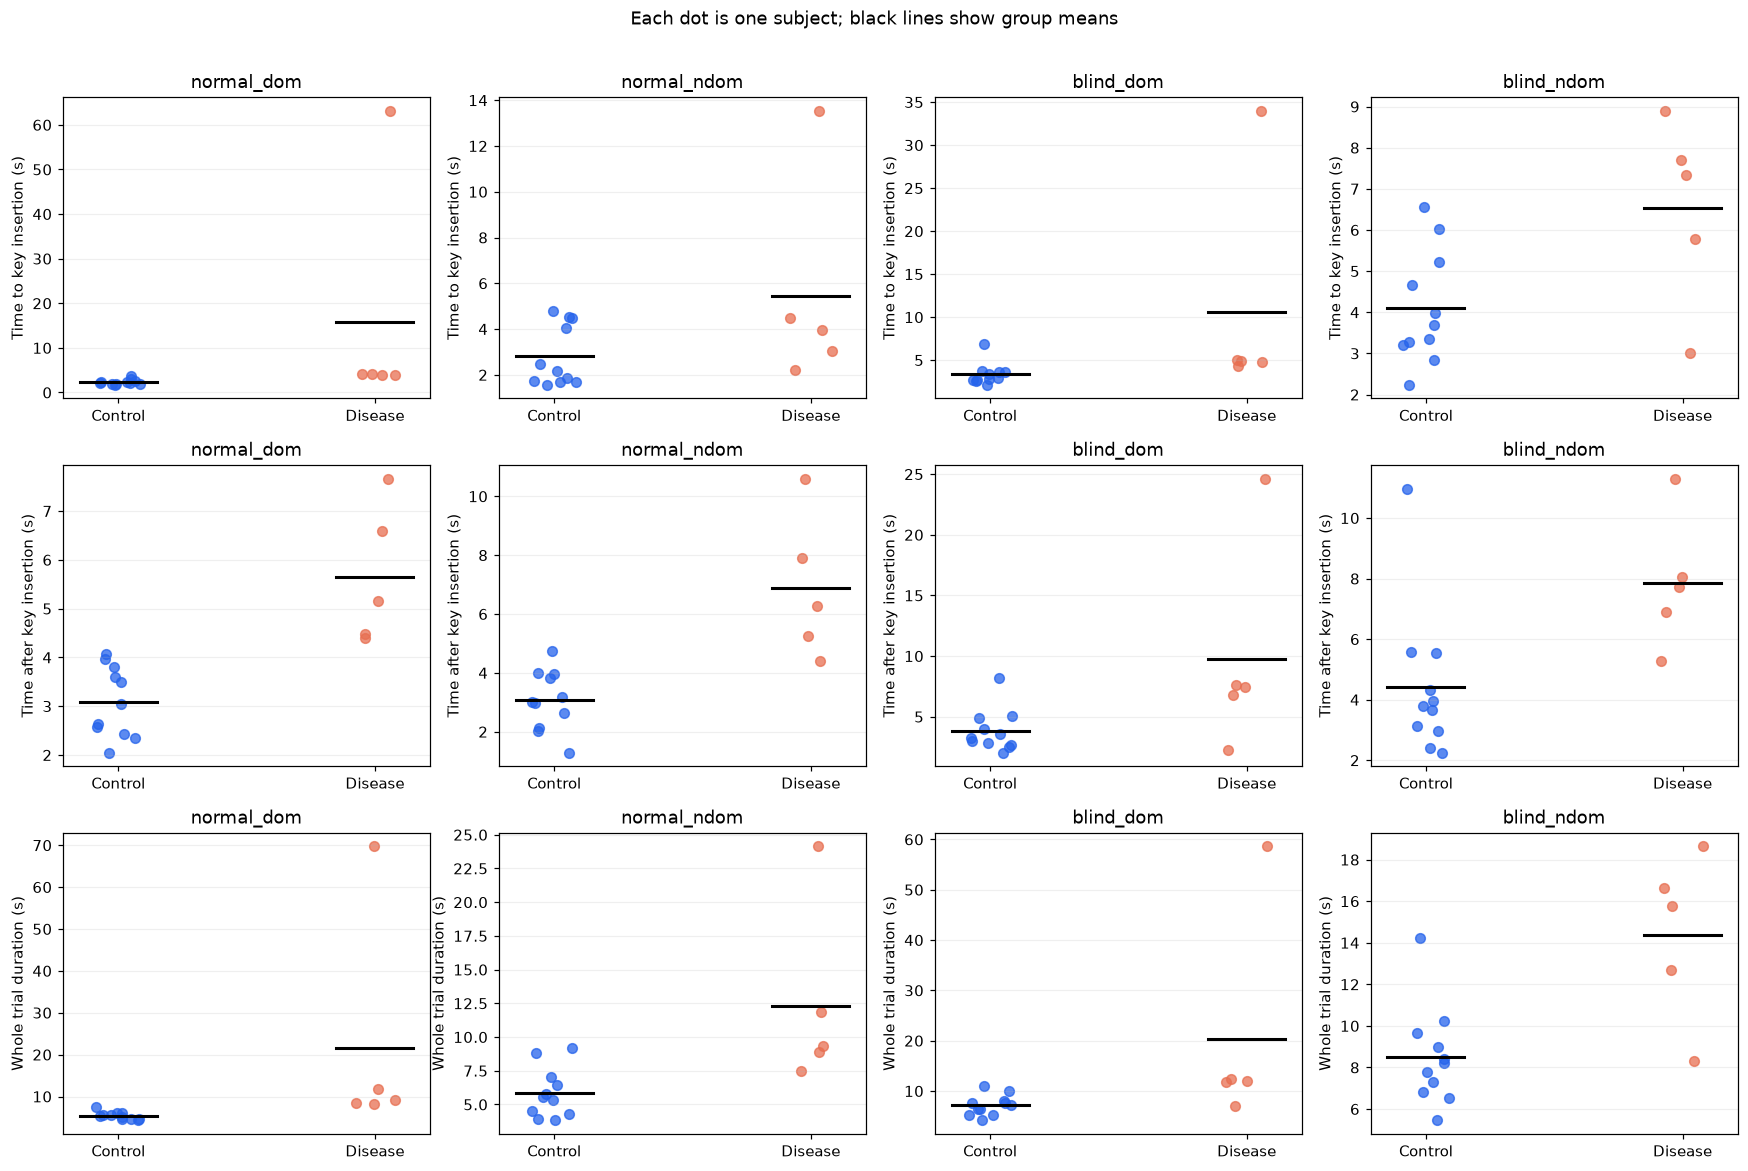

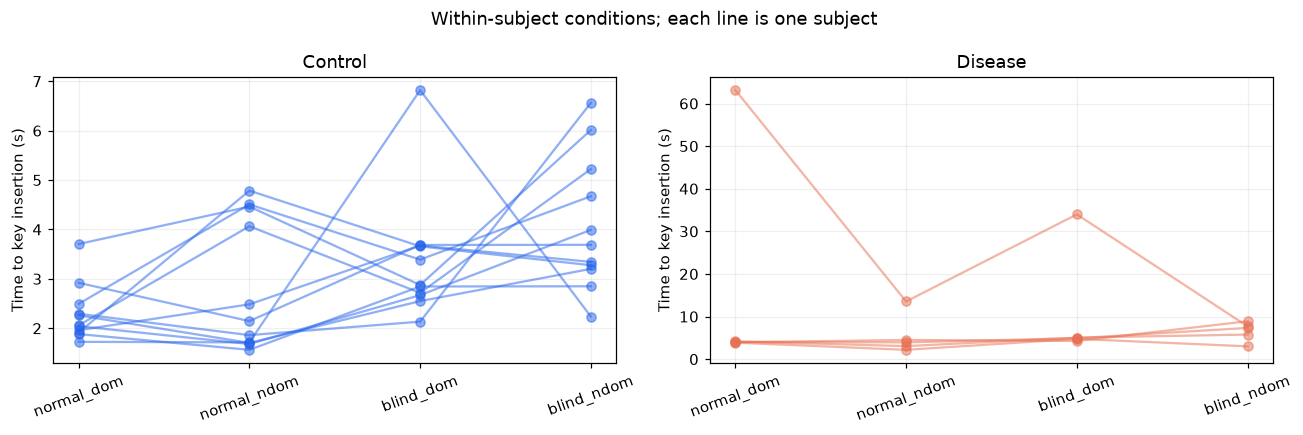

In [5]:
analysis_trials = trial_metrics.copy()
# Manual timing can be usable even when hand landmarks fail QC.
for metric in OUTCOMES:
    if metric not in TASK_OUTCOMES:
        analysis_trials.loc[~trial_metrics.analysis_eligible, metric] = float("nan")
valid_timing = (analysis_trials.status == "completed") & (analysis_trials.annotation_status == "annotated") & (analysis_trials.error == "")
analysis_trials["analysis_eligible"] = (analysis_trials.analysis_eligible | valid_timing) & ~analysis_trials.manually_excluded
if SUCCESSFUL_TASKS_ONLY:
    analysis_trials.loc[analysis_trials.task_outcome != "success", "analysis_eligible"] = False
subjects = subject_summary(analysis_trials, metrics=OUTCOMES)
descriptives = descriptive_statistics(subjects, metrics=OUTCOMES)
display(subjects)
display(descriptives)
if not subjects.empty:
    display(subjects.groupby("group").subject_name.nunique().rename("unique_subjects"))
    display(subjects.pivot(index=["subject_name", "group"], columns="experiment_type", values="trial_count").fillna(0))
    distribution_figure = plot_group_distributions(subjects, metrics=OUTCOMES)
    display_figure_once(distribution_figure)
    plt.close("all")
    paired_figure = plot_paired_conditions(subjects, metric=OUTCOMES[0])
    display_figure_once(paired_figure)
    plt.close("all")
else:
    print("Group summaries need eligible, annotated trials with control/disease labels. Use the replay section to annotate, then rerun from metrics.")


## 4. Control vs disease, separately by condition

Welch's two-sided t-test compares independent **subject** means and allows unequal group variances. The effect direction is **disease minus control**. Results include a 95% CI for the mean difference and Hedges' g (approximate small-sample correction). Mann–Whitney is a separate sensitivity analysis of distributions; it is not automatically a median test. Small samples use the exact method without ties; small tied samples use reproducible permutations (up to 9,999); otherwise an asymptotic test is used. The chosen method is reported. See [SciPy Mann–Whitney methods](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

Holm correction spans all four conditions and all selected outcomes, separately for each test family. Unavailable tests remain NaN. At least two subjects per group are required; this is a computational minimum, not a sample-size recommendation. Small cohorts give unstable estimates; assess distributions and study design before inference. Choose outcomes before inspecting p-values. No automatic normality-test-based test selection is used. See [SciPy Welch test and CI](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).


In [6]:
between_groups = compare_groups(subjects, metrics=OUTCOMES)
display(between_groups)


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,normal_dom,time_to_key_seconds,11,5,13.540692,-19.291121,46.372505,0.905195,0.316080,0.000458,exact,,1.000000,0.005495
1,normal_dom,post_key_duration_seconds,11,5,2.563058,0.825647,4.300470,2.482556,0.012810,0.000458,exact,,0.153717,0.005495
2,normal_dom,recording_duration_seconds,11,5,16.103751,-17.415498,49.623000,1.053475,0.253215,0.000458,exact,,1.000000,0.005495
3,normal_ndom,time_to_key_seconds,11,5,2.630066,-3.037115,8.297246,0.918200,0.273918,0.180403,exact,,1.000000,0.229853
4,normal_ndom,post_key_duration_seconds,11,5,3.817412,0.824784,6.810039,2.302943,0.022609,0.000916,exact,,0.240630,0.008242
5,normal_ndom,recording_duration_seconds,11,5,6.447477,-1.906181,14.801135,1.543897,0.100388,0.003205,exact,,0.702713,0.025641
6,blind_dom,time_to_key_seconds,11,5,7.231751,-8.985680,23.449182,0.967073,0.284220,0.005495,exact,,1.000000,0.038462
7,blind_dom,post_key_duration_seconds,11,5,5.944087,-4.674261,16.562436,1.165214,0.197665,0.114927,exact,,1.000000,0.229853
8,blind_dom,recording_duration_seconds,11,5,13.175838,-13.480943,39.832619,1.072016,0.242613,0.013278,exact,,1.000000,0.079670
9,blind_ndom,time_to_key_seconds,11,5,2.447545,-0.310277,5.205367,1.383423,0.072004,0.068681,exact,,0.576036,0.206044


## 5. Paired condition changes and group differences in those changes

Within each group, compare blind minus normal separately for dominant and nondominant trials, and nondominant minus dominant separately for normal and blind trials. Only subjects with both measurements enter a contrast. Paired t-tests use one difference per subject and have Holm adjustment across all requested contrasts/outcomes/groups.

The second table compares these **subject-level changes** between disease and control using Welch tests (difference of differences). This explores group-by-condition effects without pretending repeated conditions are independent. Its Holm correction is a separate family spanning all contrasts/outcomes. These contrasts are not a full mixed-effects factorial model and do not adjust for age, medication, task duration, or other covariates.


In [7]:
paired_effects, change_group_differences = paired_condition_effects(subjects, metrics=OUTCOMES)
display(paired_effects)
display(change_group_differences)


,metric,contrast,group,n_pairs,mean_change,ci_low,ci_high,p_paired,note,p_paired_holm
0,time_to_key_seconds,blind_minus_normal_dom,control,11,1.069639,0.044178,2.095100,0.042473,,0.891932
1,time_to_key_seconds,blind_minus_normal_dom,disease,5,-5.239302,-21.843245,11.364640,0.430439,,1.000000
2,time_to_key_seconds,blind_minus_normal_ndom,control,11,1.280317,0.267036,2.293598,0.018307,,0.402746
3,time_to_key_seconds,blind_minus_normal_ndom,disease,5,1.097796,-3.976340,6.171933,0.580425,,1.000000
4,time_to_key_seconds,ndom_minus_dom_normal,control,11,0.519666,-0.317559,1.356891,0.196761,,1.000000
5,time_to_key_seconds,ndom_minus_dom_normal,disease,5,-10.390961,-37.630769,16.848847,0.349268,,1.000000
6,time_to_key_seconds,ndom_minus_dom_blind,control,11,0.730344,-0.844221,2.304908,0.325718,,1.000000
7,time_to_key_seconds,ndom_minus_dom_blind,disease,5,-4.053862,-19.749706,11.641981,0.512963,,1.000000
8,post_key_duration_seconds,blind_minus_normal_dom,control,11,0.728542,-0.247414,1.704498,0.127232,,1.000000
9,post_key_duration_seconds,blind_minus_normal_dom,disease,5,4.109571,-5.934133,14.153276,0.319389,,1.000000


,metric,contrast,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm
0,time_to_key_seconds,blind_minus_normal_dom,11,5,-6.308941,-22.885245,10.267362,-0.821227,0.351568,0.509615,exact,,1.0
1,time_to_key_seconds,blind_minus_normal_ndom,11,5,-0.182521,-5.188606,4.823565,-0.068232,0.926956,0.583333,exact,,1.0
2,time_to_key_seconds,ndom_minus_dom_normal,11,5,-10.910627,-38.138974,16.317721,-0.876152,0.328578,0.089744,exact,,1.0
3,time_to_key_seconds,ndom_minus_dom_blind,11,5,-4.784206,-20.414111,10.845699,-0.642393,0.446963,0.913004,exact,,1.0
4,post_key_duration_seconds,blind_minus_normal_dom,11,5,3.381029,-6.622911,13.384970,0.711204,0.404595,0.742674,exact,,1.0
5,post_key_duration_seconds,blind_minus_normal_ndom,11,5,-0.381952,-3.466846,2.702942,-0.150146,0.780445,0.913004,exact,,1.0
6,post_key_duration_seconds,ndom_minus_dom_normal,11,5,1.254353,-1.390044,3.898751,0.841963,0.272483,0.319597,exact,,1.0
7,post_key_duration_seconds,ndom_minus_dom_blind,11,5,-2.508628,-12.771324,7.754068,-0.467048,0.545782,0.826923,exact,,1.0
8,recording_duration_seconds,blind_minus_normal_dom,11,5,-2.927912,-10.210597,4.354772,-0.782275,0.336002,0.377289,exact,,1.0
9,recording_duration_seconds,blind_minus_normal_ndom,11,5,-0.564473,-8.492861,7.363915,-0.141030,0.856256,0.913004,exact,,1.0


## 6. Replay hand landmarks and inspect individual trials

Select a trial and click **Load replay**. Play/pause and the slider follow recording time; rotate/zoom the view with the mouse. Frames are capped to limit notebook size, and missing detections are blanked rather than interpolated. The skeleton shows 21 landmarks with hand connections; z is estimated wrist-relative depth, so this is not a measured physical 3D scene. Anatomical labels are used when available; legacy detection indices remain explicitly unidentified.

The plots below the replay show the selected task hand's relative trajectory, pinch distance, and speed. If metric configuration is missing, replay still works. All JavaScript is embedded locally; no data or animation requires a network service.

The animation highlights key insertion in gold, labels the event time, marks it on the time slider, and provides a **Key in lock** jump button. Time-series plots show a vertical event line; the trajectory marks the selected fingertip at that time when detections are available. These indicate event timing, not a measured key/object location.

The review controls contain just the insertion time and notes. Success is assumed. Correct the time, click **Save event time**, reload the replay, and rerun analysis cells to update results.


In [8]:
# Retire the old widget/view before creating a replacement.
if "trial_review_widget" in globals():
    trial_review_widget.close()
trial_review_widget = review_widget(
    inventory, hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE, max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS,
)
display(trial_review_widget)


## 7. Export tables and analysis configuration

Exports go to `analysis_exports/` beside `data/`; acquisition CSVs are preserved. Re-running replaces these review exports. They contain participant names, so treat them like the source data. No example/synthetic observations are mixed into study results.


In [9]:
if not inventory.empty:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tables = {
        "inventory": inventory, "trial_metrics": trial_metrics, "subject_metrics": subjects,
        "descriptives": descriptives, "group_comparisons": between_groups,
        "paired_effects": paired_effects, "group_change_comparisons": change_group_differences,
        "whole_trial_subject_metrics": whole_trial_subjects,
        "whole_trial_descriptives": whole_trial_descriptives,
        "whole_trial_group_comparisons": whole_trial_comparisons,
        "overall_subject_metrics": overall_subjects,
        "overall_descriptives": overall_descriptives,
        "overall_group_comparisons": overall_comparisons,
    }
    for name, table in tables.items():
        table.to_csv(EXPORT_DIR / f"{name}.csv", index=False)
    if not subjects.empty:
        distribution_figure.savefig(EXPORT_DIR / "group_distributions.png", dpi=200, bbox_inches="tight")
        distribution_figure.savefig(EXPORT_DIR / "group_distributions.pdf", bbox_inches="tight")
        paired_figure.savefig(EXPORT_DIR / "paired_conditions.png", dpi=200, bbox_inches="tight")
    configuration = {
        "data_dir": str(DATA_DIR), "outcomes": OUTCOMES, "whole_trial_outcomes": WHOLE_TRIAL_OUTCOMES,
        "excluded_recordings": EXCLUDED_RECORDINGS,
        "dominant_hands": DOMINANT_HANDS, "hand_selections": hand_selections,
        "allow_legacy_hand_index": ALLOW_LEGACY_HAND_INDEX,
        "legacy_image_size": LEGACY_IMAGE_SIZE, "min_frames": MIN_FRAMES,
        "min_coverage": MIN_COVERAGE, "min_duration_seconds": MIN_DURATION_SECONDS,
        "min_handedness_confidence": MIN_HANDEDNESS_CONFIDENCE,
        "max_derivative_gap_seconds": MAX_DERIVATIVE_GAP_SECONDS,
        "successful_tasks_only": SUCCESSFUL_TASKS_ONLY, "min_rest_phase_frames": MIN_REST_PHASE_FRAMES,
    }
    (EXPORT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2) + "\n")
    print(f"Exported tables, figures, and configuration to {EXPORT_DIR}")
else:
    print("No acquired data to export yet.")


Exported tables, figures, and configuration to /home/jakub/Projects/proj/analysis_exports


## 8. Report analysis following the MS pilot-study guidelines

This section is the report analysis specified in **Statistische Auswertung der MS.pdf**. Earlier t-test tables remain supplementary. User-confirmed decisions: average **all eligible completed trials**, exclude `test`, `test1`, `test2`, `test3`, and merge `Yoconda1` into `Yoconda`. The existing unfinished-trial exclusion remains in force. Each participant contributes one trial mean per condition, then one equal-weight mean across all four conditions for the primary overall comparison. Missing conditions are not imputed.

**Primary endpoint:** recording duration is a **Total Task Duration proxy**, including initial/final waiting and operator reaction time. Its timing eligibility does not depend on hand detection or availability of an insertion marker. **P1 Reach and P2 Grasp are unavailable** because no phase boundaries were recorded; time to insertion cannot substitute for these phases. Time to insertion and post-insertion duration are additional exploratory timings.

**Velocity:** peak speed of the 2D wrist-relative index fingertip, normalized by the fixed median palm length, in palm lengths/s. Movement units count strict local speed maxima exceeding 10% of the entire recording's maximum speed. Peaks are found within consecutive valid speed runs; gaps are never bridged and segment endpoints are not counted. No smoothing, prominence, or minimum peak spacing is imposed. These estimates include rest and tracking noise, depend on sampling rate, and are not calibrated object/hand transport velocities. The PDF's healthy reference range cannot be applied to this signal without validating the measurement protocol.

**Tests:** two-sided Mann–Whitney U for independent groups; two-sided Wilcoxon signed-rank for paired changes. Positive effects mean MS > controls, eyes closed > open, or nondominant > dominant. Wilcoxon excludes zero differences from ranks; sign permutations are used for up to 20 pairs (up to 9,999 permutations, seed 42), otherwise asymptotic inference. The paired test assumes a symmetric difference distribution for a location-shift interpretation. Mann–Whitney compares distributions, and is not generally a test of medians.

The main hand and vision changes average over the other factor and require all four conditions. Stratified changes use complete pairs only. Group-specific and pooled paired tests are reported separately; pooled results describe this combined cohort. Each table has its own Holm family across its reported tests. Primary overall duration is reported separately without adjustment as the prespecified single primary test; other comparisons are exploratory.

Effect sizes: independent rank-biserial correlation = 2U/(n_MS n_control) − 1; paired rank-biserial correlation = signed rank sum / total nonzero rank sum. Independent effect CIs and paired median-change CIs use 2,000 participant bootstrap resamples with seed 42. These percentile intervals can be unstable in this small pilot sample. Paired median-change CIs describe changes in seconds or outcome units, not the paired rank effect. Report exact subject/pair counts, median, IQR, and individual values alongside p-values.


Outcome availability


,guideline_outcome,available_measure,status
0,Total Task Duration,Recording duration proxy,Proxy approved; includes waiting/operator time
1,P1 Reach duration,NaN,Unavailable: no phase boundaries
2,P2 Grasp duration,NaN,Unavailable: no phase boundaries
3,Peak Velocity,Peak wrist-relative fingertip speed,Exploratory; palm lengths/s
4,Movement Units,Local speed peaks >10% global maximum,Exploratory; tracking/sampling dependent


Participant and trial flow


,group,source_subject_name,subject_name,experiment_type,recorded_trials,timing_trials,motion_trials,manually_excluded
0,control,Consti,Consti,blind_dom,2,2,2,0
1,control,Consti,Consti,blind_ndom,2,2,2,0
2,control,Consti,Consti,normal_dom,2,2,2,0
3,control,Consti,Consti,normal_ndom,2,2,2,0
4,control,Elena,Elena,blind_dom,1,1,1,0
...,...,...,...,...,...,...,...,...
59,disease,ms4,ms4,normal_ndom,2,2,2,0
60,disease,ms5,ms5,blind_dom,2,2,2,0
61,disease,ms5,ms5,blind_ndom,2,2,2,0
62,disease,ms5,ms5,normal_dom,2,2,2,0


Individual condition means and outcome-specific repeat counts


...

,subject_name,group,metric,contrast,difference
0,Consti,control,recording_duration_seconds,delta_vision_dom,2.341761
1,Consti,control,recording_duration_seconds,delta_vision_ndom,1.508351
2,Consti,control,recording_duration_seconds,delta_hand_open,-0.037625
3,Consti,control,recording_duration_seconds,delta_hand_closed,-0.871035
4,Consti,control,recording_duration_seconds,delta_vision,1.925056
...,...,...,...,...,...
445,ms5,disease,movement_units,delta_vision_ndom,7.000000
446,ms5,disease,movement_units,delta_hand_open,-6.500000
447,ms5,disease,movement_units,delta_hand_closed,7.000000
448,ms5,disease,movement_units,delta_vision,0.250000


Wilcoxon paired comparisons


,metric,contrast,group,n_pairs,n_nonzero,median_change,statistic,p,rank_biserial,change_ci_low,change_ci_high,method,note,p_holm
0,movement_units,delta_hand,control,10,10,2.625000,10.0,0.083984,0.636364,-0.500000,11.037500,"sign permutations, seed 42",,1.0
1,movement_units,delta_hand,disease,5,5,0.250000,7.0,1.000000,0.066667,-78.000000,21.500000,"sign permutations, seed 42",,1.0
2,movement_units,delta_hand,pooled,15,15,2.250000,32.0,0.118400,0.466667,-1.250000,16.000000,"sign permutations, seed 42",,1.0
3,movement_units,delta_hand_closed,control,10,10,6.750000,12.5,0.142578,0.545455,-4.000000,18.268750,"sign permutations, seed 42",,1.0
4,movement_units,delta_hand_closed,disease,5,5,7.000000,4.5,0.500000,0.400000,-14.000000,49.000000,"sign permutations, seed 42",,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,time_to_key_seconds,delta_vision_dom,disease,5,5,0.879873,5.0,0.625000,0.333333,-29.156208,0.891567,"sign permutations, seed 42",,1.0
86,time_to_key_seconds,delta_vision_dom,pooled,15,15,0.796089,23.0,0.032800,0.616667,0.288663,0.891644,"sign permutations, seed 42",,1.0
87,time_to_key_seconds,delta_vision_ndom,control,10,10,1.327769,6.0,0.027344,0.781818,0.512510,1.670915,"sign permutations, seed 42",,1.0
88,time_to_key_seconds,delta_vision_ndom,disease,5,5,2.715746,5.0,0.625000,0.333333,-5.829942,4.391678,"sign permutations, seed 42",,1.0


Group comparisons of changes


,metric,contrast,n_control,n_disease,u,p,rank_biserial,effect_ci_low,effect_ci_high,median_difference,method,note,p_holm
0,movement_units,delta_hand,10,5,21.0,0.678655,-0.16,-0.8400,0.560,-2.375000,exact,,1.0
1,movement_units,delta_hand_closed,10,5,24.0,0.929071,-0.04,-0.7600,0.640,0.250000,"permutation, seed 42",,1.0
2,movement_units,delta_hand_open,10,5,12.5,0.137862,-0.50,-1.0000,0.260,-8.500000,"permutation, seed 42",,1.0
3,movement_units,delta_vision,10,5,13.0,0.164502,-0.48,-1.0000,0.280,-6.250000,exact,,1.0
4,movement_units,delta_vision_dom,10,5,8.0,0.039960,-0.68,-1.0000,-0.200,-6.500000,exact,,1.0
5,movement_units,delta_vision_ndom,10,5,16.5,0.327006,-0.34,-0.9405,0.360,-11.500000,"permutation, seed 42",,1.0
6,peak_velocity,delta_hand,10,5,31.0,0.513487,0.24,-0.4000,0.841,7.551466,exact,,1.0
7,peak_velocity,delta_hand_closed,10,5,24.0,0.953047,-0.04,-0.6800,0.640,0.980853,exact,,1.0
8,peak_velocity,delta_hand_open,10,5,33.0,0.370962,0.32,-0.2800,0.840,4.210973,exact,,1.0
9,peak_velocity,delta_vision,10,5,28.0,0.767899,0.12,-0.5200,0.680,2.121578,exact,,1.0


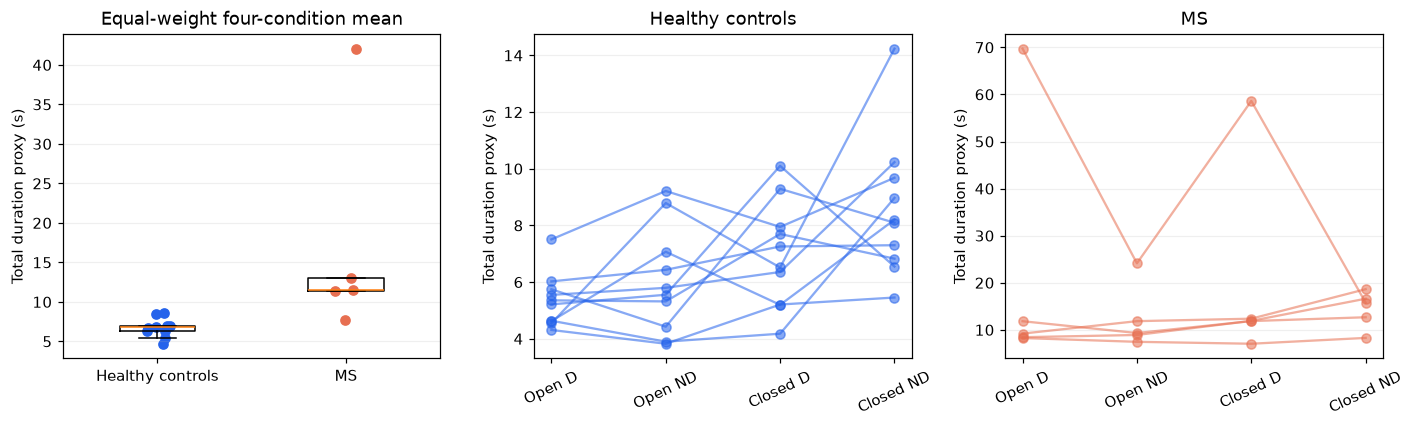

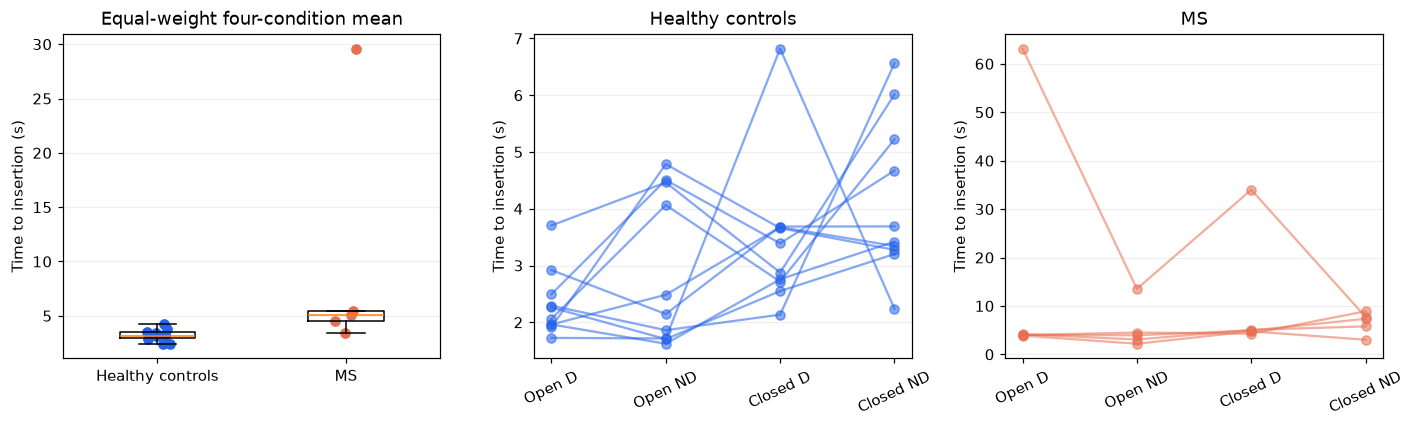

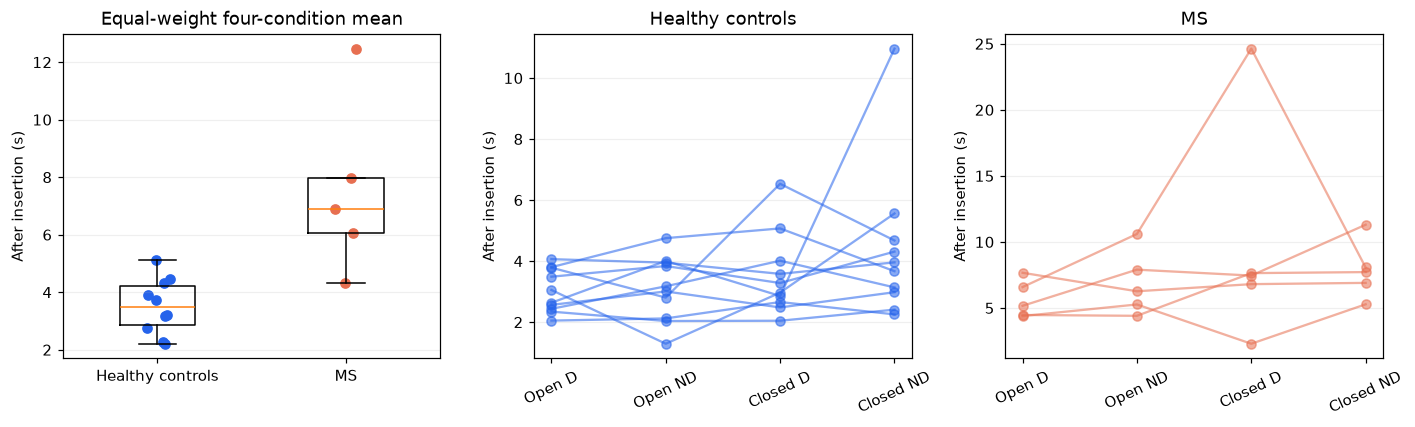

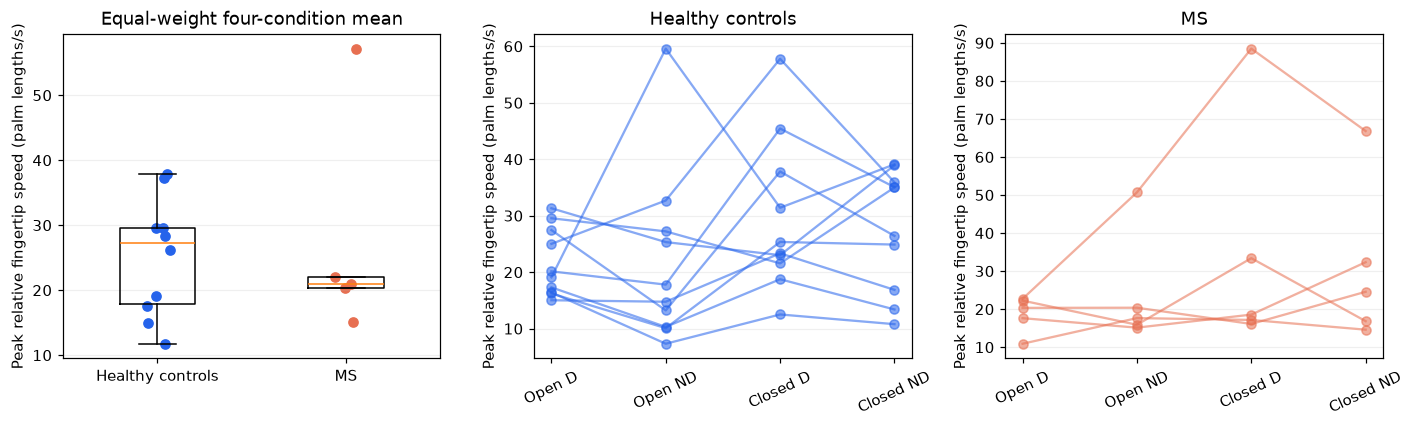

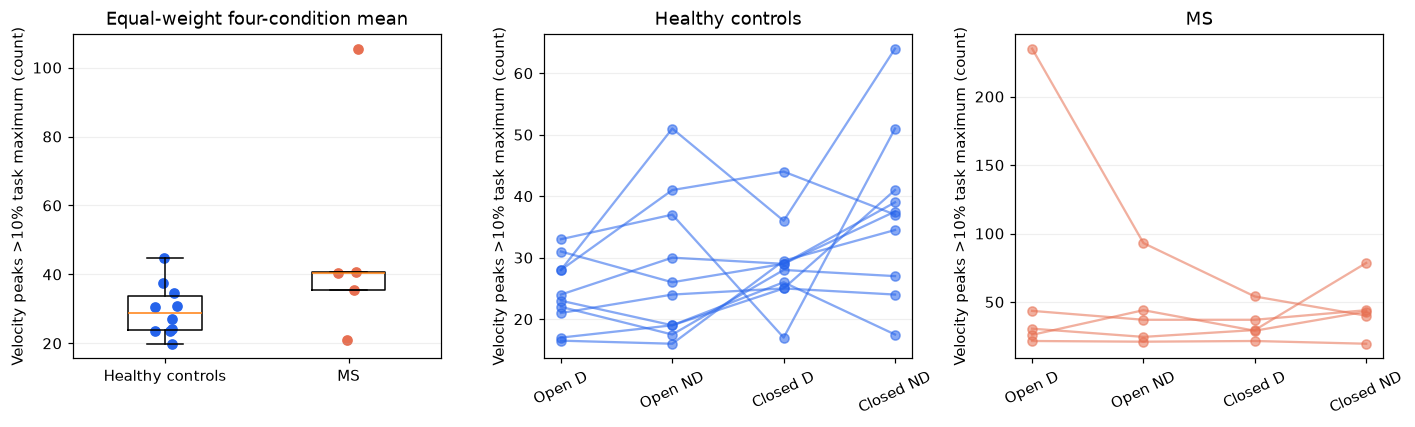

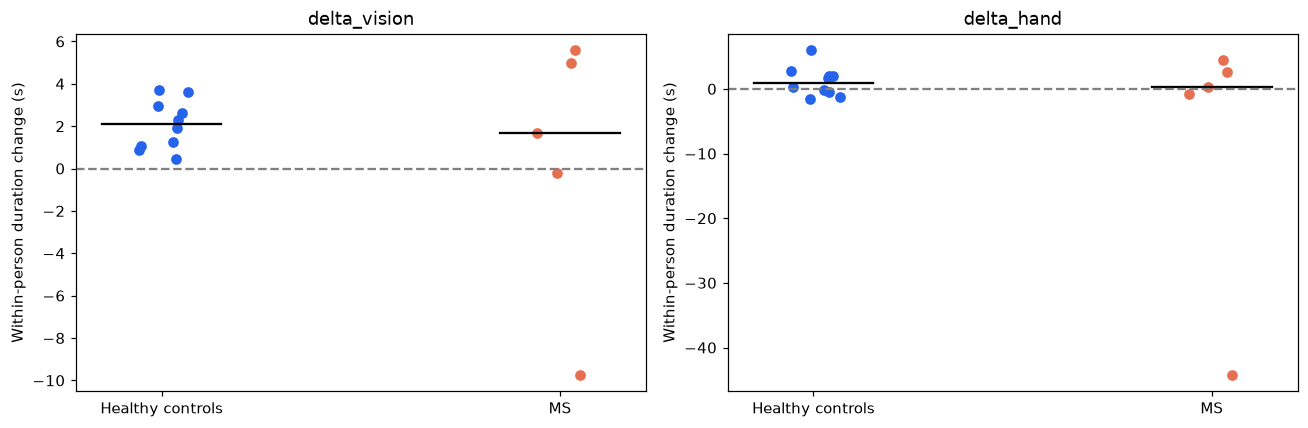

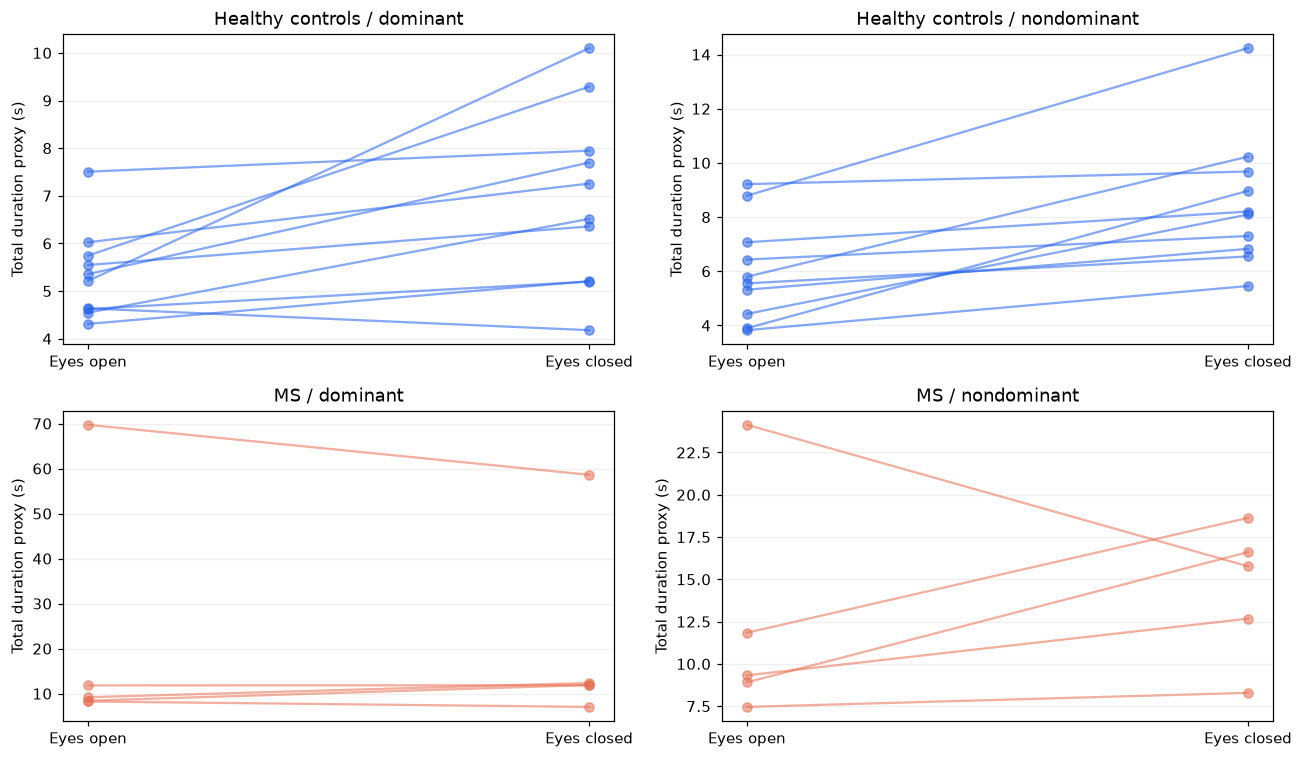

In [10]:
from proj.report_analysis import (
    REPORT_METRICS, LABELS, report_trials, aggregate_report, group_tests,
    condition_changes, paired_tests, change_tests, report_figures,
)

REPORT_EXCLUDED_SUBJECTS = ["test", "test1", "test2", "test3"]
REPORT_SUBJECT_ALIASES = {"Yoconda1": "Yoconda"}
report_trial_table = report_trials(
    trial_metrics, hand_selections,
    excluded_subjects=REPORT_EXCLUDED_SUBJECTS, subject_aliases=REPORT_SUBJECT_ALIASES,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE, max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS,
)
report_subjects = aggregate_report(report_trial_table)
report_overall = balanced_overall_summary(report_subjects, metrics=REPORT_METRICS)
report_descriptives = descriptive_statistics(report_subjects, metrics=REPORT_METRICS)
report_overall_descriptives = descriptive_statistics(report_overall, metrics=REPORT_METRICS)
for table in [report_descriptives, report_overall_descriptives]:
    table["iqr"] = table.q3 - table.q1
report_groups = group_tests(report_subjects)
report_overall_groups = group_tests(report_overall)
report_primary = report_overall_groups.loc[report_overall_groups.metric == "recording_duration_seconds"].drop(columns="p_holm").copy()
report_changes = condition_changes(report_subjects)
report_paired = paired_tests(report_changes)
report_change_groups = change_tests(report_changes)
report_flow = report_trial_table.groupby(["group", "source_subject_name", "subject_name", "experiment_type"]).agg(
    recorded_trials=("trial_id", "size"), timing_trials=("timing_eligible", "sum"),
    motion_trials=("motion_eligible", "sum"), manually_excluded=("manually_excluded", "sum"),
).reset_index()
report_availability = pd.DataFrame([
    {"guideline_outcome": "Total Task Duration", "available_measure": "Recording duration proxy", "status": "Proxy approved; includes waiting/operator time"},
    {"guideline_outcome": "P1 Reach duration", "available_measure": None, "status": "Unavailable: no phase boundaries"},
    {"guideline_outcome": "P2 Grasp duration", "available_measure": None, "status": "Unavailable: no phase boundaries"},
    {"guideline_outcome": "Peak Velocity", "available_measure": "Peak wrist-relative fingertip speed", "status": "Exploratory; palm lengths/s"},
    {"guideline_outcome": "Movement Units", "available_measure": "Local speed peaks >10% global maximum", "status": "Exploratory; tracking/sampling dependent"},
])
for title, table in [
    ("Outcome availability", report_availability), ("Participant and trial flow", report_flow),
    ("Individual condition means and outcome-specific repeat counts", report_subjects),
    ("Descriptive statistics by condition", report_descriptives),
    ("Overall individual values", report_overall), ("Overall descriptive statistics", report_overall_descriptives),
    ("Primary overall duration comparison", report_primary),
    ("Exploratory condition group comparisons", report_groups),
    ("Exploratory overall group comparisons", report_overall_groups),
    ("Individual changes", report_changes), ("Wilcoxon paired comparisons", report_paired),
    ("Group comparisons of changes", report_change_groups),
]:
    print(title)
    display(table)
report_plots = report_figures(report_subjects, report_overall, report_changes)
for figure in report_plots.values():
    display_figure_once(figure)


In [11]:
REPORT_DIR = EXPORT_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
report_tables = {
    "trial_audit": report_trial_table, "participant_flow": report_flow,
    "outcome_availability": report_availability, "individual_condition_means": report_subjects,
    "individual_overall_means": report_overall, "descriptives_by_condition": report_descriptives,
    "descriptives_overall": report_overall_descriptives, "primary_duration_test": report_primary,
    "mannwhitney_by_condition": report_groups, "mannwhitney_overall": report_overall_groups,
    "individual_changes": report_changes, "wilcoxon_paired": report_paired,
    "mannwhitney_changes": report_change_groups,
}
for name, table in report_tables.items():
    table.to_csv(REPORT_DIR / f"{name}.csv", index=False)
for name, figure in report_plots.items():
    for extension in ["png", "pdf"]:
        figure.savefig(REPORT_DIR / f"{name}.{extension}", dpi=300, bbox_inches="tight")
report_config = dict(configuration, report_metrics=REPORT_METRICS,
    excluded_subjects=REPORT_EXCLUDED_SUBJECTS, subject_aliases=REPORT_SUBJECT_ALIASES,
    repeat_policy="all eligible completed trials; outcome-specific counts",
    duration_definition="Recording duration proxy, including waiting and operator reaction",
    velocity_definition="Unsmoothed wrist-relative index fingertip; 2D, fixed palm normalization",
    movement_units_definition="Strict local maxima >10% recording maximum, within valid runs",
    bootstrap_resamples=2000, permutation_resamples=9999, random_seed=42)
(REPORT_DIR / "configuration.json").write_text(json.dumps(report_config, indent=2) + "\n")
notes = """# Report data and figures

Use primary_duration_test.csv for the single primary overall duration comparison.
All other tests are exploratory. See descriptives_overall.csv and
individual_overall_means.csv for corresponding distributions and participant values.
Condition tables use one mean per participant and condition; *_n_trials columns
provide outcome-specific trial counts. participant_flow.csv audits exclusions and
tracking eligibility. trial_audit.csv preserves source participant names.

Total Task Duration is a recording-duration proxy; P1/P2 cannot be derived.
Motion features use wrist-relative fingertip motion and are not physical hand speed.
PNG figures are 300 dpi; PDFs provide vector output. Four-condition lines show
individual subjects; overall boxplots show individual means; duration_changes shows
individual vision/hand changes with median bars. Missing values are not imputed.

Effect directions: MS minus controls; closed minus open; nondominant minus dominant.
Independent effect CIs are percentile bootstrap rank-biserial intervals; paired CIs
are percentile bootstrap median-change intervals. See notebook for definitions.
Participant identifiers are retained in tables; acquisition files are untouched.
"""
(REPORT_DIR / "README.md").write_text(notes)
print(f"Report tables and figures exported to {REPORT_DIR}")

primary = report_primary.iloc[0]
duration_stats = report_overall_descriptives.loc[report_overall_descriptives.metric == "recording_duration_seconds"].set_index("group")
summary = ["# Primary report result", "",
    f"Analysed {report_subjects.loc[report_subjects.group == 'control', 'subject_name'].nunique()} healthy controls and {report_subjects.loc[report_subjects.group == 'disease', 'subject_name'].nunique()} MS participants.",
    f"Eligible completed trials: {int(report_trial_table.timing_eligible.sum())} for timing, {int(report_trial_table.motion_eligible.sum())} for movement.", ""]
for group in ["control", "disease"]:
    row = duration_stats.loc[group]
    summary.append(f"{group}: median {row['median']:.2f} s, IQR {row['iqr']:.2f} s (Q1 {row['q1']:.2f}, Q3 {row['q3']:.2f}); n={int(row['n_subjects'])}.")
summary += ["", f"Two-sided Mann–Whitney U={primary.u:.1f}, p={primary.p:.5f}; rank-biserial correlation={primary.rank_biserial:.2f}, bootstrap 95% CI [{primary.effect_ci_low:.2f}, {primary.effect_ci_high:.2f}].",
    "", "This endpoint is an equal-weight mean of four condition means per participant, using recording duration as an approved proxy. It includes waiting and operator reaction time. This is a pilot-study result; P1/P2 remain unavailable."]
(REPORT_DIR / "primary_result.md").write_text("\n".join(summary) + "\n")
print("\n".join(summary))


Report tables and figures exported to /home/jakub/Projects/proj/analysis_exports/report
# Primary report result

Analysed 10 healthy controls and 5 MS participants.
Eligible completed trials: 93 for timing, 92 for movement.

control: median 6.80 s, IQR 0.68 s (Q1 6.28, Q3 6.96); n=10.
disease: median 11.47 s, IQR 1.59 s (Q1 11.42, Q3 13.01); n=5.

Two-sided Mann–Whitney U=48.0, p=0.00266; rank-biserial correlation=0.92, bootstrap 95% CI [0.64, 1.00].

This endpoint is an equal-weight mean of four condition means per participant, using recording duration as an approved proxy. It includes waiting and operator reaction time. This is a pilot-study result; P1/P2 remain unavailable.
